In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [13]:
df=pd.read_csv('../Data/Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [14]:
d=['User ID','Gender']

In [15]:
df=df.drop(d,axis=1)
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


### Plot 1 — Class Distribution:

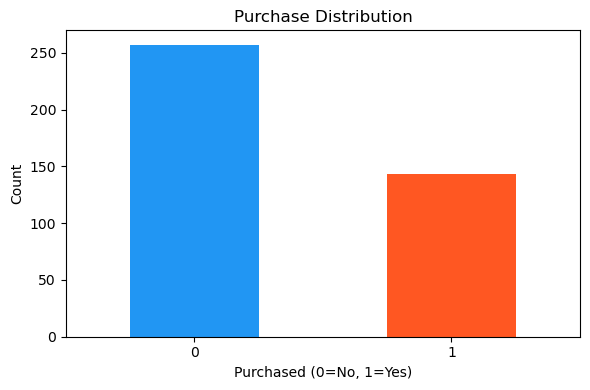

In [64]:
plt.figure(figsize=(6,4))
df['Purchased'].value_counts().plot(kind='bar', color=['#2196F3','#FF5722'])
plt.title('Purchase Distribution')
plt.xlabel('Purchased (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Plot 2 — Age vs Salary Scatter (Before Training):

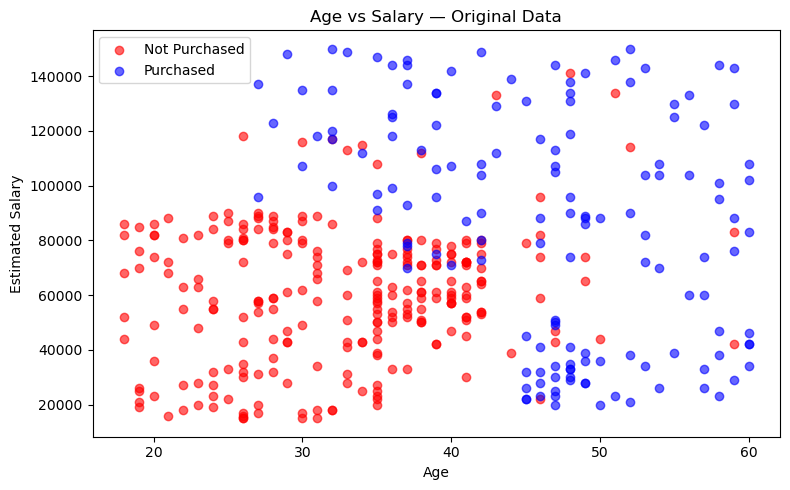

In [65]:
plt.figure(figsize=(8,5))
purchased = df[df['Purchased']==1]
not_purchased = df[df['Purchased']==0]

plt.scatter(not_purchased['Age'], not_purchased['EstimatedSalary'],
            color='red', label='Not Purchased', alpha=0.6)
plt.scatter(purchased['Age'], purchased['EstimatedSalary'],
            color='blue', label='Purchased', alpha=0.6)

plt.title('Age vs Salary — Original Data')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.tight_layout()
plt.show()

### MODELING START

In [18]:
x=df.iloc[:,0:2]
x.head()

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000


In [19]:
y=df['Purchased']
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=11)

In [25]:
sc=StandardScaler()

In [26]:
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [32]:
msv=SVC()

In [33]:
msv.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [47]:
y_pred=msv.predict(x_test)
y_pred

array([0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0], dtype=int64)

In [48]:
print(msv.score(x_test,y_test))

0.9


In [60]:
msv1=SVC(kernel='rbf', C=1, gamma='scale', probability=True)


In [61]:
msv1.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [62]:
y_pred1=msv1.predict(x_test)


In [63]:
print(msv1.score(x_test,y_test))

0.9


### Plot 3 — SVM Decision Boundary (BEST PLOT!):

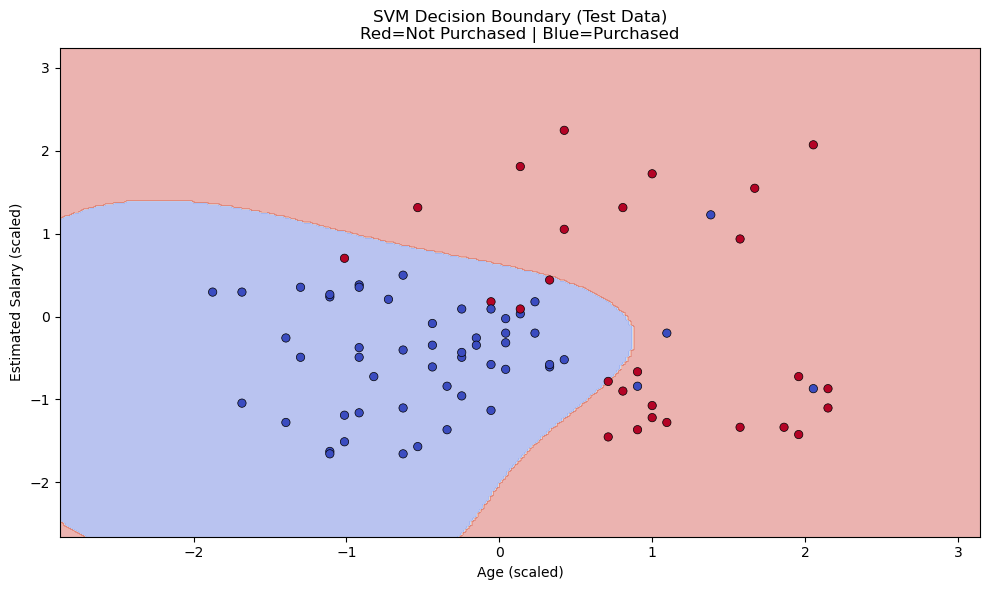

In [67]:


# Create mesh
x_min, x_max = x_test[:, 0].min()-1, x_test[:, 0].max()+1
y_min, y_max = x_test[:, 1].min()-1, x_test[:, 1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = msv.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
plt.scatter(x_test[:,0], x_test[:,1],
            c=y_test, cmap='coolwarm',
            edgecolors='black', linewidth=0.5)

plt.title('SVM Decision Boundary (Test Data)\nRed=Not Purchased | Blue=Purchased')
plt.xlabel('Age (scaled)')
plt.ylabel('Estimated Salary (scaled)')
plt.tight_layout()
plt.show()

In [55]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[49  4]
 [ 4 23]]
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        53
           1       0.85      0.85      0.85        27

    accuracy                           0.90        80
   macro avg       0.89      0.89      0.89        80
weighted avg       0.90      0.90      0.90        80



### Plot 4 — Confusion Matrix Heatmap

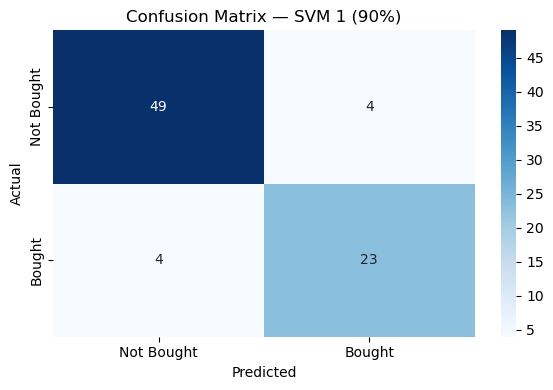

In [68]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Bought','Bought'],
            yticklabels=['Not Bought','Bought'])
plt.title('Confusion Matrix — SVM 1 (90%)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Plot 5 — Compare Both Models:

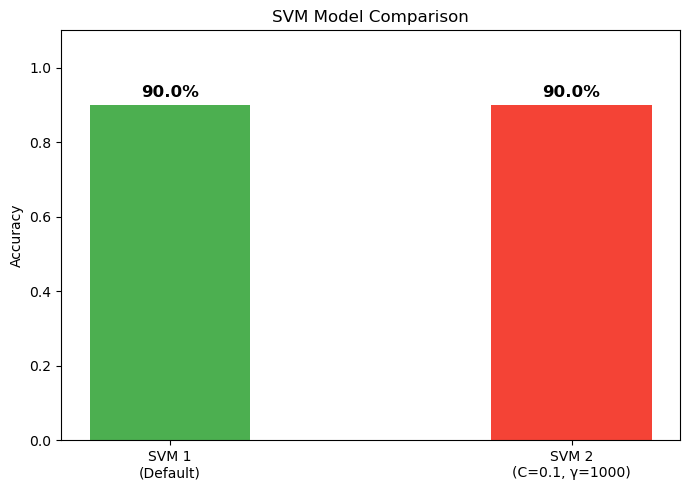

In [69]:
models = ['SVM 1\n(Default)', 'SVM 2\n(C=0.1, γ=1000)']
scores = [msv.score(x_test,y_test), msv1.score(x_test,y_test)]
colors = ['#4CAF50', '#F44336']

plt.figure(figsize=(7,5))
bars = plt.bar(models, scores, color=colors, width=0.4)
plt.ylim(0, 1.1)
plt.title('SVM Model Comparison')
plt.ylabel('Accuracy')

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{score*100:.1f}%',
             ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [59]:
print("Support Vectors per class:", msv.n_support_)
print("Total Support Vectors:", sum(msv.n_support_))

Support Vectors per class: [42 43]
Total Support Vectors: 85
